In [36]:
import itertools
import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import mlflow
import numpy as np
import pandas as pd
from mlflow.tracking import MlflowClient

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 220)
pd.set_option('display.float_format', '{:.4f}'.format)

# Color-blind-friendly palette
PALETTE = ['#0173B2', '#DE8F05', '#029E73', '#D55E00', '#CC78BC', '#CA9161']

# ── Figure export ─────────────────────────────────────────────────────────────
SAVE_FIGS = True
FIGURES_DIR = Path('figures')
FIGURES_DIR.mkdir(exist_ok=True)

def savefig(name: str):
    if SAVE_FIGS:
        for ext in ('pdf', 'png'):
            plt.savefig(FIGURES_DIR / f'{name}.{ext}', bbox_inches='tight', dpi=300)
        print(f'  Saved: figures/{name}.(pdf|png)')

In [37]:
# ── MLflow & metric definitions ────────────────────────────────────────────────
MLFLOW_TRACKING_URI = 'http://localhost:8567'
RAGAS_TABLE_ARTIFACT = 'ragas_scores.json'

METRIC_COLS = [
    'faithfulness',
    # 'context_precision',
    # 'context_recall',
    'answer_relevance',
    # 'factual_correctness',
    'factual_correctness_recall',
]

METRIC_SHORT = {
    'faithfulness':             'Faith.',
    'context_precision':        'Ctx.Prec.',
    'context_recall':           'Ctx.Rec.',
    'answer_relevance':         'Ans.Rel.',
    'factual_correctness':      'FC',
    'factual_correctness_recall': 'FCRec.',
}

METRIC_LONG = {
    'faithfulness':             'Faithfulness',
    'context_precision':        'Context Precision',
    'context_recall':           'Context Recall',
    'answer_relevance':         'Answer Relevance',
    'factual_correctness':      'Factual Correctness',
    'factual_correctness_recall': 'FC Recall',
}

EXCLUDE_CLASSES = ['unanswerable']

# ── Run definitions ────────────────────────────────────────────────────────────

# Axis 1: Search Strategy  (fixed: Baseline arch + gpt-4o-mini)
AXIS1_RUNS = [
    ('f6d783f661a644a58865384534021c32', 'Semantic'),
    ('144d504d4b1b454f8505f54697c69250', 'BM25'),
    ('2ebab2b7d6ad46859eab992a06c5ccad', 'Hybrid'),
]

# Axis 2: Architecture  (fixed: Hybrid search + gpt-4o-mini)
AXIS2_RUNS = [
    ('2ebab2b7d6ad46859eab992a06c5ccad', 'Baseline'),
    ('412a730db5e04a4da436218d6321d1cd', 'Query Rewriting'),
    ('9df381d8997646e797d34917dd394dee', 'RAG Agent'),
]
('9df381d8997646e797d34917dd394dee', 'gpt-4o-mini'),
# Axis 3: LLM Model  (fixed: RAG Agent arch + Hybrid search)
AXIS3_RUNS = [
    ('7e34b19e653d4df09f9dc59d9a488d86', 'gemma4:e4b\n(local)'),
    # ('801c6a24a60b4f689a38fcdb1de87e49', 'qwen3.5:9b\n(local)'), # run 1
    ('64308a1718224160b777630198d0c1ad', 'qwen3.5:9b\n(local)'), # run 2
    ('9df381d8997646e797d34917dd394dee', 'gpt-4o-mini'),
    # ('9d312a36ef2f4332b200b620919bd202', 'gpt-5.4'), # run 1
    ('7021198023d34038929cdeebe7cbea4c', 'gpt-5.4'), # run 2
]

# Reproducibility: same config, two independent runs
REPRO_RUNS = [
    ('f6d783f661a644a58865384534021c32', 'Run 1 (original)'),
    ('79ac6798bfab4f228fdb0cb88a30bb16', 'Run 2 (repeat)'),
]

# Judge comparison: same precomputed answers, 4 different judges
JUDGE_RUNS = [
    ('53fdfeda71b644028d483906ed9cb406', 'gpt-4o-mini'),
    ('c8da3550a0a145f1aac8805d2ee6c733', 'gpt-5.4-mini'),
    ('38c7e3a1d5b14453a2cdb78089fa7df8', 'gpt-5.4'),
    ('8a415f2a5acb41469ddc499ba0e4a73d', 'prometheus2:7b'),
]


# Full 3x3 grid: architecture x search strategy (all gpt-4o-mini)
ARCHS    = ['Baseline', 'Query Rewriting', 'RAG Agent']
SEARCHES = ['Semantic', 'BM25', 'Hybrid']
GRID_IDS = {
    ('Baseline',        'Semantic'): 'f6d783f661a644a58865384534021c32',
    ('Baseline',        'BM25'):     '144d504d4b1b454f8505f54697c69250',
    ('Baseline',        'Hybrid'):   '2ebab2b7d6ad46859eab992a06c5ccad',
    ('Query Rewriting', 'Semantic'): '92647f9427f74a0ea710d0cf731ec0ea',
    ('Query Rewriting', 'BM25'):     'e5483a9635b34c8895ecdfabc45674c4',
    ('Query Rewriting', 'Hybrid'):   '412a730db5e04a4da436218d6321d1cd',
    ('RAG Agent',       'Semantic'): '7b33b7a6b88b420e93d6c56f8bca4416',
    ('RAG Agent',       'BM25'):     '2c80aecbb48d4bf68efce97806509159',
    ('RAG Agent',       'Hybrid'):   '9df381d8997646e797d34917dd394dee',
}

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
client = MlflowClient()
print(f'Tracking URI: {MLFLOW_TRACKING_URI}')
print(f'Total unique runs to load: ...')

Tracking URI: http://localhost:8567
Total unique runs to load: ...


In [38]:
# ── Helper functions ───────────────────────────────────────────────────────────

def _list_artifacts(run_id: str, path: str = '') -> list:
    items = []
    for art in client.list_artifacts(run_id, path):
        items.append(art.path)
        if art.is_dir:
            items.extend(_list_artifacts(run_id, art.path))
    return items


def load_run(run_id: str) -> pd.DataFrame:
    matches = [p for p in _list_artifacts(run_id) if p.endswith(RAGAS_TABLE_ARTIFACT)]
    if not matches:
        raise FileNotFoundError(f'No {RAGAS_TABLE_ARTIFACT} for {run_id}')
    local = client.download_artifacts(run_id, matches[0])
    with open(local) as f:
        payload = json.load(f)
    if isinstance(payload, list):
        df = pd.DataFrame(payload)
    elif 'data' in payload:
        df = pd.DataFrame(payload['data'], columns=payload['columns'])
    else:
        df = pd.DataFrame(payload)
    for col in METRIC_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df


def mean_scores(df: pd.DataFrame, exclude=EXCLUDE_CLASSES) -> pd.Series:
    """Mean RAGAS scores, optionally excluding question classes."""
    sub = df[~df['question_class'].isin(exclude)] if exclude else df
    return sub[METRIC_COLS].mean(numeric_only=True)


def build_table(runs: list, exclude=EXCLUDE_CLASSES) -> pd.DataFrame:
    """Build a rows=labels, cols=metrics comparison table."""
    rows = {label: mean_scores(all_data[rid], exclude=exclude) for rid, label in runs}
    return pd.DataFrame(rows).T


def styled(df: pd.DataFrame, caption: str = ''):
    """Return a green-red gradient styled DataFrame for display."""
    return (
        df.style
        .format('{:.4f}')
        .background_gradient(axis=0, cmap='RdYlGn', vmin=0.35, vmax=0.95)
        .set_caption(caption)
    )


def plot_grouped_bars(ax, table: pd.DataFrame, title: str, ylim=(0, 1.18)):
    """Grouped bar chart: rows=labels, cols=metrics."""
    metrics = [m for m in METRIC_COLS if m in table.columns]
    short = [METRIC_SHORT[m] for m in metrics]
    labels = list(table.index)
    x = np.arange(len(metrics))
    n = len(labels)
    w = 0.8 / n
    for i, label in enumerate(labels):
        scores = table.loc[label, metrics].values.astype(float)
        offset = (i - (n - 1) / 2) * w
        bars = ax.bar(x + offset, scores, w * 0.9, label=label, color=PALETTE[i % len(PALETTE)])
        for bar, v in zip(bars, scores):
            if not np.isnan(v):
                ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008,
                        f'{v:.3f}', ha='center', va='bottom', fontsize=6.5, rotation=90)
    ax.set_xticks(x)
    ax.set_xticklabels(short, rotation=20, ha='right')
    ax.set_ylim(*ylim)
    ax.set_ylabel('Mean Score (excl. unanswerable)')
    ax.set_title(title)
    ax.legend(loc='upper right', framealpha=0.8)


def plot_delta_bars(ax, delta: pd.DataFrame, title: str):
    """Grouped delta bar chart vs a baseline row with per-series visual styles."""
    metrics = [m for m in METRIC_COLS if m in delta.columns]
    short = [METRIC_SHORT[m] for m in metrics]
    labels = list(delta.index)
    x = np.arange(len(metrics))
    n = len(labels)
    w = 0.78 / n
    hatches = ['', '//', '\\\\', 'xx', '..', '++', 'oo']

    for i, label in enumerate(labels):
        vals = delta.loc[label, metrics].values.astype(float)
        offset = (i - (n - 1) / 2) * w
        edge = PALETTE[i % len(PALETTE)]
        hatch = hatches[i % len(hatches)]

        for xi, v in zip(x + offset, vals):
            # Positive deltas are filled; negative deltas are hollow with the same series style.
            face = edge if v >= 0 else 'white'
            ax.bar(
                xi,
                v,
                w * 0.9,
                color=face,
                edgecolor=edge,
                hatch=hatch,
                linewidth=1.1,
                alpha=0.9,
            )

        for xi, v in zip(x + offset, vals):
            if not np.isnan(v) and abs(v) > 0.002:
                ax.text(
                    xi,
                    v + (0.005 if v >= 0 else -0.018),
                    f'{v:+.3f}',
                    ha='center',
                    va='bottom' if v >= 0 else 'top',
                    fontsize=7,
                )

    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(short, rotation=20, ha='right')
    ax.set_ylabel('Δ Score')
    ax.set_title(title)

    handles = [
        mpatches.Patch(facecolor='white', edgecolor=PALETTE[i % len(PALETTE)], hatch=hatches[i % len(hatches)], label=lbl)
        for i, lbl in enumerate(labels)
    ]
    ax.legend(handles=handles, loc='upper right', framealpha=0.85)


def plot_radar(ax_polar, table: pd.DataFrame, title: str):
    """Radar / spider chart on a polar axes."""
    metrics = [m for m in METRIC_COLS if m in table.columns]
    short = [METRIC_SHORT[m] for m in metrics]
    N = len(metrics)
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]
    for i, label in enumerate(table.index):
        vals = table.loc[label, metrics].values.astype(float).tolist()
        vals += vals[:1]
        ax_polar.plot(angles, vals, color=PALETTE[i % len(PALETTE)], linewidth=2, label=label)
        ax_polar.fill(angles, vals, color=PALETTE[i % len(PALETTE)], alpha=0.12)
    ax_polar.set_xticks(angles[:-1])
    ax_polar.set_xticklabels(short, fontsize=8)
    ax_polar.set_ylim(0, 1)
    ax_polar.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax_polar.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=6)
    ax_polar.set_title(title, pad=14, fontsize=10)
    ax_polar.legend(loc='upper right', bbox_to_anchor=(1.45, 1.2), fontsize=8)


def plot_score_heatmap(ax, df: pd.DataFrame, title: str,
                       vmin: float = 0.35, vmax: float = 0.95,
                       row_label: str = '', col_label: str = 'Metric'):
    """Heatmap: rows=runs/groups, cols=metrics."""
    metrics = [m for m in METRIC_COLS if m in df.columns]
    data = df[metrics].astype(float)
    cols_short = [METRIC_SHORT[m] for m in metrics]
    im = ax.imshow(data.values, cmap='RdYlGn', vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels(cols_short, fontsize=9)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(list(data.index), fontsize=9)
    for r in range(data.shape[0]):
        for c in range(data.shape[1]):
            v = data.iloc[r, c]
            if not np.isnan(v):
                ax.text(c, r, f'{v:.3f}', ha='center', va='center', fontsize=8,
                        color='black' if 0.4 < v < 0.85 else 'white')
    ax.set_xlabel(col_label)
    if row_label:
        ax.set_ylabel(row_label)
    ax.set_title(title, fontsize=10, fontweight='bold')

print('Helper functions loaded.')

Helper functions loaded.


In [39]:
# ── Load all run data from MLflow ──────────────────────────────────────────────
ALL_RUN_IDS: set = set()
for runs in [AXIS1_RUNS, AXIS2_RUNS, AXIS3_RUNS, REPRO_RUNS, JUDGE_RUNS]:
    for rid, _ in runs:
        ALL_RUN_IDS.add(rid)
ALL_RUN_IDS.update(GRID_IDS.values())

print(f'Loading {len(ALL_RUN_IDS)} unique runs...')
all_data: dict[str, pd.DataFrame] = {}

for run_id in sorted(ALL_RUN_IDS):
    try:
        all_data[run_id] = load_run(run_id)
        print(f'  OK   {run_id[:8]}  ({len(all_data[run_id])} rows)')
    except Exception as e:
        print(f'  FAIL {run_id[:8]}: {e}')

print(f'\nLoaded {len(all_data)}/{len(ALL_RUN_IDS)} runs successfully.')

Loading 17 unique runs...


  OK   144d504d  (20 rows)


  OK   2c80aecb  (20 rows)


  OK   2ebab2b7  (20 rows)


  OK   38c7e3a1  (20 rows)


...

  OK   92647f94  (20 rows)


  OK   9df381d8  (20 rows)


  OK   c8da3550  (20 rows)


  OK   e5483a96  (20 rows)


  OK   f6d783f6  (20 rows)

Loaded 17/17 runs successfully.


In [40]:
# ── 5.1.8 Axis 3: LLM Model ────────────────────────────────────────────────────
# Clean labels for display (remove the \n)
AXIS3_RUNS_CLEAN = [
    ('9df381d8997646e797d34917dd394dee', 'gpt-4o-mini'),
    ('7e34b19e653d4df09f9dc59d9a488d86', 'gemma4:e4b (local)'),
    # ('801c6a24a60b4f689a38fcdb1de87e49', 'qwen3.5:9b (local)'), # run 1
    ('64308a1718224160b777630198d0c1ad', 'qwen3.5:9b (local)'), # run 2
    # ('9d312a36ef2f4332b200b620919bd202', 'gpt-5.4'), # run 1
    ('7021198023d34038929cdeebe7cbea4c', 'gpt-5.4'), # run 2
]
axis3_table = build_table(AXIS3_RUNS_CLEAN)

print('=== Axis 3: LLM Model (RAG Agent, Hybrid search, excl. unanswerable) ===')
display(styled(axis3_table, 'Table 5.4: LLM Model Comparison — Mean RAGAS Scores'))

delta_a3 = axis3_table.subtract(axis3_table.loc['gpt-4o-mini'])
print('\nDelta vs gpt-4o-mini (positive = improvement):')
display(
    delta_a3.iloc[1:].style.format('{:+.4f}')
    .background_gradient(cmap='RdYlGn', vmin=-0.20, vmax=0.20)
    .set_caption('Table 5.4b: Delta vs gpt-4o-mini')
)

=== Axis 3: LLM Model (RAG Agent, Hybrid search, excl. unanswerable) ===


,faithfulness,answer_relevance,factual_correctness_recall
gpt-4o-mini,0.7156,0.9044,0.7053
gemma4:e4b (local),0.6497,0.8304,0.7669
qwen3.5:9b (local),0.7463,0.8994,0.7608
gpt-5.4,0.8234,0.8171,0.9083



Delta vs gpt-4o-mini (positive = improvement):


,faithfulness,answer_relevance,factual_correctness_recall
gemma4:e4b (local),-0.0659,-0.0740,+0.0616
qwen3.5:9b (local),+0.0307,-0.0051,+0.0554
gpt-5.4,+0.1078,-0.0874,+0.2030


In [41]:
# ── 5.1.10 Load token metrics from MLflow ──────────────────────────────────────

# Model metadata for efficiency metrics.
# params_B  — exact for open-source (from official model cards), None for closed API
# price_*   — USD per 1M tokens; 0.0 for locally-hosted (no API cost), None if unknown
MODEL_METADATA = {
    # Open-source: parameter counts from official model cards (exact, not estimated)
    'gemma4:e4b':   {'params_B': 4.3,  'price_input_per_1M': 0.0,   'price_output_per_1M': 0.0},
    'qwen3.5:9b':   {'params_B': 9.0,  'price_input_per_1M': 0.0,   'price_output_per_1M': 0.0},
    # Commercial API: architecture undisclosed → params_B=None; pricing from provider docs
    'gpt-4o-mini':  {'params_B': None, 'price_input_per_1M': 0.15,  'price_output_per_1M': 0.60},
    'gpt-5.4':      {'params_B': None, 'price_input_per_1M': 2.50,  'price_output_per_1M': 15.00},  # TODO: verify current pricing
}

TOKEN_METRIC_KEYS = [
    'total_llm_calls',
    'total_llm_input_tokens',
    'total_llm_output_tokens',
    'rag_phase_runtime_s',
]

def load_token_metrics(run_id: str) -> dict:
    run = client.get_run(run_id)
    m = run.data.metrics
    p = run.data.params
    result = {k: m.get(k, np.nan) for k in TOKEN_METRIC_KEYS}
    result['llm_model'] = p.get('llm_model', '')
    return result


def build_efficiency_table(runs: list, exclude=EXCLUDE_CLASSES) -> pd.DataFrame:
    """Build a table combining RAGAS scores with token usage and efficiency metrics."""
    rows = []
    for rid, label in runs:
        scores = mean_scores(all_data[rid], exclude=exclude)
        composite = scores[METRIC_COLS].mean()
        tokens = load_token_metrics(rid)
        input_tokens  = tokens['total_llm_input_tokens']
        output_tokens = tokens['total_llm_output_tokens']
        runtime_s     = tokens['rag_phase_runtime_s']
        input_k       = input_tokens / 1000
        total_tokens  = input_tokens + output_tokens

        meta      = MODEL_METADATA.get(tokens.get('llm_model', ''), {})
        params_b  = meta.get('params_B')
        price_in  = meta.get('price_input_per_1M')
        price_out = meta.get('price_output_per_1M')

        # score_per_second: directly measured wall-clock time; works for all models
        score_per_s = round(composite / runtime_s, 6) if runtime_s > 0 else np.nan

        # score_per_PFLOP: FLOPs ≈ 2 × params × total_tokens (Chinchilla standard)
        # Exact for open-source (published params); NaN for closed API (undisclosed architecture)
        if params_b is not None and total_tokens > 0:
            pflops = (2 * params_b * 1e9 * total_tokens) / 1e15
            score_per_pflop = round(composite / pflops, 4)
        else:
            score_per_pflop = np.nan

        # score_per_dollar: API pricing from provider docs; NaN for local (no API cost) or unknown pricing
        if price_in is not None and price_out is not None:
            cost_usd = (input_tokens * price_in + output_tokens * price_out) / 1e6
            score_per_dollar = round(composite / cost_usd, 4) if cost_usd > 0 else np.nan
        else:
            score_per_dollar = np.nan

        rows.append({
            'label':               label,
            'composite_score':     composite,
            **{METRIC_SHORT[m]: scores[m] for m in METRIC_COLS},
            'llm_calls':           int(tokens['total_llm_calls']) if not np.isnan(tokens['total_llm_calls']) else np.nan,
            'input_tokens_K':      round(input_k, 1),
            'output_tokens_K':     round(output_tokens / 1000, 1),
            'total_tokens_K':      round(total_tokens / 1000, 1),
            'runtime_s':           round(runtime_s, 1),
            'score_per_1k_tokens': round(composite / input_k, 4) if input_k > 0 else np.nan,
            'score_per_second':    score_per_s,
            'score_per_PFLOP':     score_per_pflop,
            'score_per_dollar':    score_per_dollar,
        })
    df = pd.DataFrame(rows).set_index('label')
    return df


EFF_FORMAT = {
    'composite_score':     '{:.4f}',
    'llm_calls':           '{:.0f}',
    'input_tokens_K':      '{:.1f}K',
    'output_tokens_K':     '{:.1f}K',
    'runtime_s':           '{:.1f}s',
    'score_per_1k_tokens': '{:.4f}',
    'score_per_second':    '{:.4f}',
    'score_per_PFLOP':     '{:.4f}',
    'score_per_dollar':    '{:.4f}',
}
EFF_SCORE_COLS   = ['composite_score', 'score_per_1k_tokens', 'score_per_second', 'score_per_dollar']
EFF_EFFORT_COLS  = ['input_tokens_K', 'runtime_s']


# ── Axis 1: Search strategy efficiency ────────────────────────────────────────
eff_axis1 = build_efficiency_table(AXIS1_RUNS)
print('=== Axis 1: Search Strategy — Effort vs. Quality ===')
display(
    eff_axis1[['composite_score', 'llm_calls', 'input_tokens_K', 'output_tokens_K', 'runtime_s',
               'score_per_1k_tokens', 'score_per_second', 'score_per_dollar']]
    .style.format(EFF_FORMAT, na_rep='N/A')
    .background_gradient(cmap='RdYlGn', subset=EFF_SCORE_COLS, axis=0)
    .background_gradient(cmap='YlOrRd', subset=EFF_EFFORT_COLS, axis=0)
    .set_caption('Table 5.6a: Search Strategy — Effort vs. Score')
)

# ── Axis 2: Architecture efficiency ───────────────────────────────────────────
eff_axis2 = build_efficiency_table(AXIS2_RUNS)
print('\n=== Axis 2: Architecture — Effort vs. Quality ===')
display(
    eff_axis2[['composite_score', 'llm_calls', 'input_tokens_K', 'output_tokens_K', 'runtime_s',
               'score_per_1k_tokens', 'score_per_second', 'score_per_dollar']]
    .style.format(EFF_FORMAT, na_rep='N/A')
    .background_gradient(cmap='RdYlGn', subset=EFF_SCORE_COLS, axis=0)
    .background_gradient(cmap='YlOrRd', subset=EFF_EFFORT_COLS, axis=0)
    .set_caption('Table 5.6b: Architecture — Effort vs. Score')
)

# Cost multiplier vs Baseline
base_row = eff_axis2.loc['Baseline']
print('\nCost multiplier vs Baseline architecture:')
multipliers = pd.DataFrame({
    'calls_multiplier':  eff_axis2['llm_calls'] / base_row['llm_calls'],
    'tokens_multiplier': eff_axis2['input_tokens_K'] / base_row['input_tokens_K'],
    'score_gain':        eff_axis2['composite_score'] - base_row['composite_score'],
}).round(3)
display(multipliers.style.format('{:+.3f}', subset=['score_gain'])
        .format('{:.2f}×', subset=['calls_multiplier', 'tokens_multiplier'])
        .background_gradient(cmap='YlOrRd', subset=['calls_multiplier', 'tokens_multiplier'], axis=0)
        .background_gradient(cmap='RdYlGn', subset=['score_gain'], vmin=-0.05, vmax=0.10, axis=0)
        .set_caption('Table 5.6c: Architecture Cost Multiplier vs Baseline (Hybrid search, gpt-4o-mini)')
)

# ── Axis 3: LLM efficiency ─────────────────────────────────────────────────────
eff_axis3 = build_efficiency_table(AXIS3_RUNS_CLEAN)
print('\n=== Axis 3: LLM Model — Effort vs. Quality ===')
display(
    eff_axis3[['composite_score', 'llm_calls', 'input_tokens_K', 'output_tokens_K', 'runtime_s',
               'score_per_1k_tokens', 'score_per_second', 'score_per_PFLOP', 'score_per_dollar']]
    .style.format(EFF_FORMAT, na_rep='N/A')
    .background_gradient(cmap='RdYlGn', subset=EFF_SCORE_COLS + ['score_per_PFLOP'], axis=0)
    .background_gradient(cmap='YlOrRd', subset=['input_tokens_K', 'output_tokens_K', 'runtime_s'], axis=0)
    .set_caption('Table 5.6d: LLM Model — Effort vs. Score (RAG Agent, Hybrid search)\n'
                 'score_per_PFLOP: exact for open-source; N/A for closed API (undisclosed architecture)\n'
                 'score_per_dollar: N/A for local models (no API cost)')
)

=== Axis 1: Search Strategy — Effort vs. Quality ===


,composite_score,llm_calls,input_tokens_K,output_tokens_K,runtime_s,score_per_1k_tokens,score_per_second,score_per_dollar
label,,,,,,,,
Semantic,0.7069,20,32.8K,2.0K,58.5s,0.0216,0.0121,115.0127
BM25,0.7510,20,40.3K,2.0K,52.7s,0.0187,0.0143,104.0135
Hybrid,0.7591,20,36.4K,1.8K,42.6s,0.0209,0.0178,116.6083



=== Axis 2: Architecture — Effort vs. Quality ===


,composite_score,llm_calls,input_tokens_K,output_tokens_K,runtime_s,score_per_1k_tokens,score_per_second,score_per_dollar
label,,,,,,,,
Baseline,0.7591,20,36.4K,1.8K,42.6s,0.0209,0.0178,116.6083
Query Rewriting,0.7749,40,39.7K,2.1K,88.3s,0.0195,0.0088,107.3265
RAG Agent,0.7751,43,62.6K,4.4K,119.0s,0.0124,0.0065,64.3064



Cost multiplier vs Baseline architecture:


,calls_multiplier,tokens_multiplier,score_gain
label,,,
Baseline,1.00×,1.00×,+0.000
Query Rewriting,2.00×,1.09×,+0.016
RAG Agent,2.15×,1.72×,+0.016



=== Axis 3: LLM Model — Effort vs. Quality ===


,composite_score,llm_calls,input_tokens_K,output_tokens_K,runtime_s,score_per_1k_tokens,score_per_second,score_per_PFLOP,score_per_dollar
label,,,,,,,,,
gpt-4o-mini,0.7751,43,62.6K,4.4K,119.0s,0.0124,0.0065,N/A,64.3064
gemma4:e4b (local),0.7490,40,61.3K,12.6K,175.2s,0.0122,0.0043,1.1794,N/A
qwen3.5:9b (local),0.8022,43,76.9K,10.7K,216.1s,0.0104,0.0037,0.5088,N/A
gpt-5.4,0.8496,42,68.6K,6.1K,137.3s,0.0124,0.0062,N/A,3.2336


  Saved: figures/fig_5_13_token_efficiency.(pdf|png)


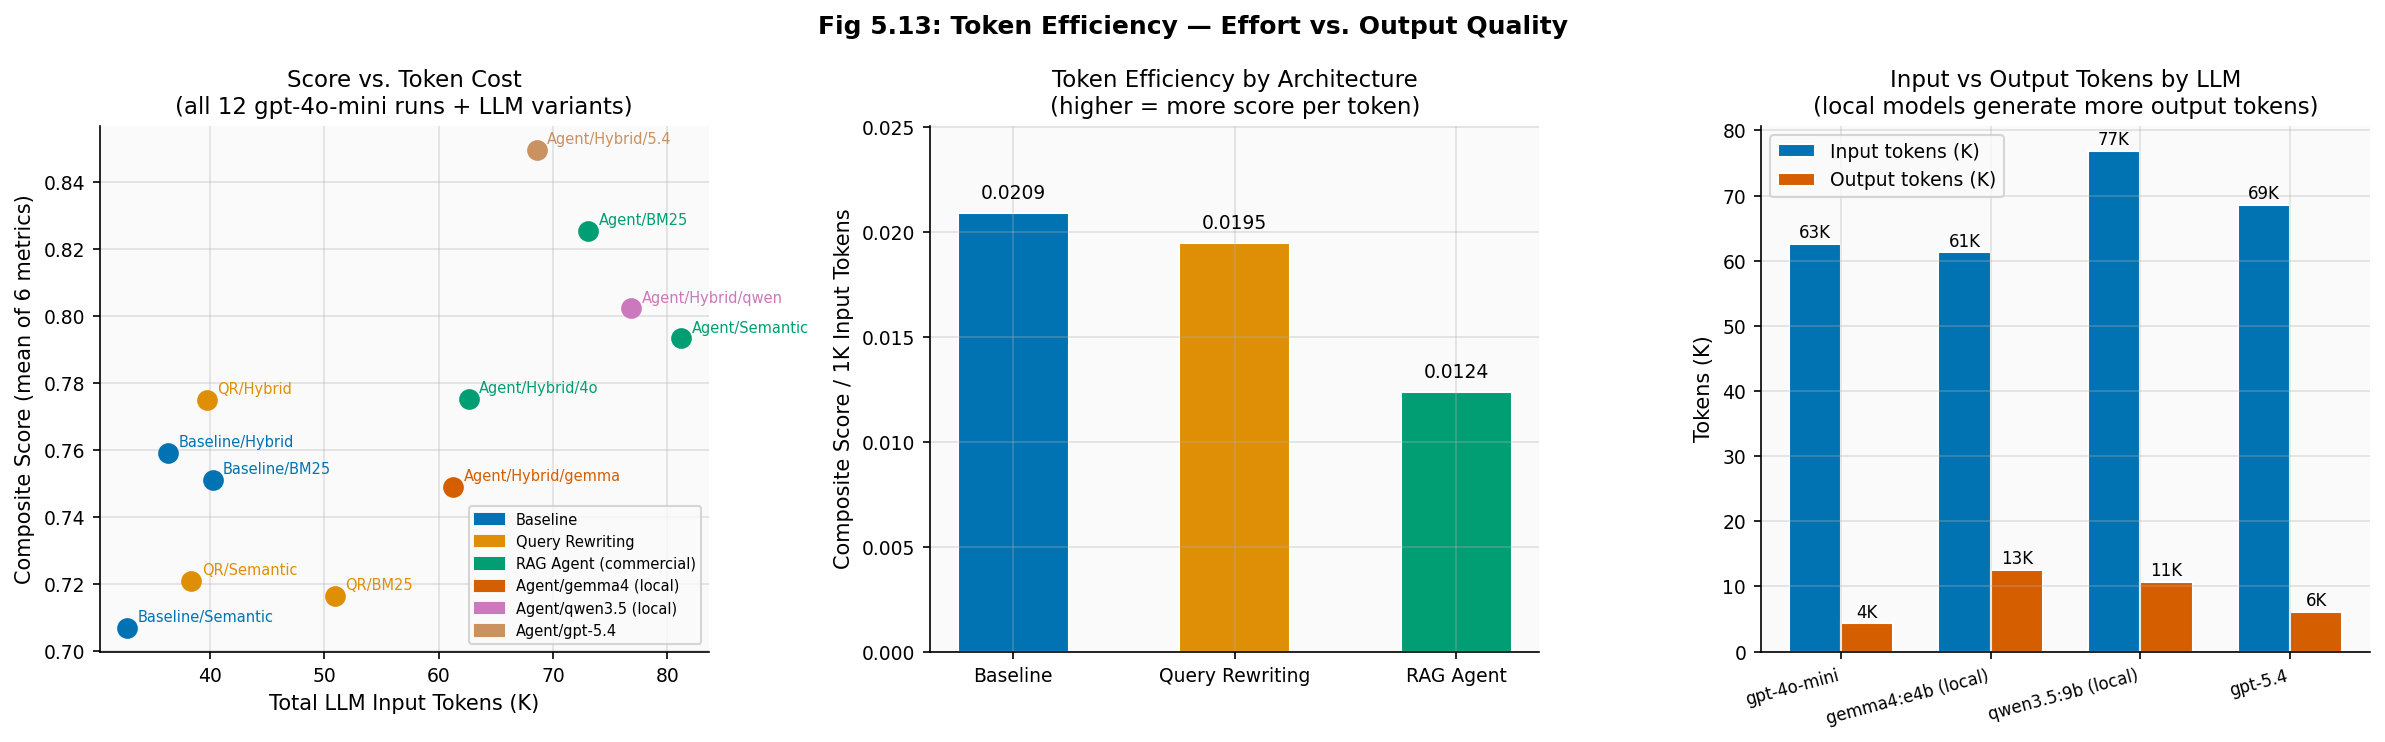

In [42]:
# ── Fig 5.13: Scatter + bar — Architecture efficiency ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# ── Plot 1: Scatter — all 12 runs (composite score vs input tokens) ────────────
ALL_RUNS_EFF = [
    ('f6d783f661a644a58865384534021c32', 'Baseline/Semantic', PALETTE[0]),
    ('144d504d4b1b454f8505f54697c69250', 'Baseline/BM25',     PALETTE[0]),
    ('2ebab2b7d6ad46859eab992a06c5ccad', 'Baseline/Hybrid',   PALETTE[0]),
    ('92647f9427f74a0ea710d0cf731ec0ea', 'QR/Semantic',       PALETTE[1]),
    ('e5483a9635b34c8895ecdfabc45674c4', 'QR/BM25',           PALETTE[1]),
    ('412a730db5e04a4da436218d6321d1cd', 'QR/Hybrid',         PALETTE[1]),
    ('7b33b7a6b88b420e93d6c56f8bca4416', 'Agent/Semantic',    PALETTE[2]),
    ('2c80aecbb48d4bf68efce97806509159', 'Agent/BM25',        PALETTE[2]),
    ('9df381d8997646e797d34917dd394dee', 'Agent/Hybrid/4o',   PALETTE[2]),
    ('7e34b19e653d4df09f9dc59d9a488d86', 'Agent/Hybrid/gemma',PALETTE[3]),
    # ('801c6a24a60b4f689a38fcdb1de87e49', 'Agent/Hybrid/qwen', PALETTE[4]), # run 1
    ('64308a1718224160b777630198d0c1ad', 'Agent/Hybrid/qwen', PALETTE[4]), # run 2
    # ('9d312a36ef2f4332b200b620919bd202', 'Agent/Hybrid/5.4',  PALETTE[5]), # run 1
    ('7021198023d34038929cdeebe7cbea4c', 'Agent/Hybrid/5.4',  PALETTE[5]), # run 2
]

ax = axes[0]
arch_legend = {
    'Baseline':     mpatches.Patch(color=PALETTE[0], label='Baseline'),
    'Query Rewrit.':mpatches.Patch(color=PALETTE[1], label='Query Rewrit.'),
    'RAG Agent':    mpatches.Patch(color=PALETTE[2], label='RAG Agent'),
    'Agent/local':  mpatches.Patch(color=PALETTE[3], label='Agent (local model)'),
}

for rid, label, color in ALL_RUNS_EFF:
    tokens = load_token_metrics(rid)
    score = mean_scores(all_data[rid])[METRIC_COLS].mean()
    x_val = tokens['total_llm_input_tokens'] / 1000
    ax.scatter(x_val, score, color=color, s=80, zorder=3)
    ax.annotate(label, (x_val, score), textcoords='offset points',
                xytext=(5, 3), fontsize=7, color=color)

ax.set_xlabel('Total LLM Input Tokens (K)')
ax.set_ylabel('Composite Score (mean of 6 metrics)')
ax.set_title('Score vs. Token Cost\n(all 12 gpt-4o-mini runs + LLM variants)')
legend_handles = [
    mpatches.Patch(color=PALETTE[0], label='Baseline'),
    mpatches.Patch(color=PALETTE[1], label='Query Rewriting'),
    mpatches.Patch(color=PALETTE[2], label='RAG Agent (commercial)'),
    mpatches.Patch(color=PALETTE[3], label='Agent/gemma4 (local)'),
    mpatches.Patch(color=PALETTE[4], label='Agent/qwen3.5 (local)'),
    mpatches.Patch(color=PALETTE[5], label='Agent/gpt-5.4'),
]
ax.legend(handles=legend_handles, fontsize=7, loc='lower right')

# ── Plot 2: Score-per-1K-tokens — architecture axis ────────────────────────────
ax = axes[1]
labels2 = list(eff_axis2.index)
vals2 = eff_axis2['score_per_1k_tokens'].values
colors2 = PALETTE[:len(labels2)]
bars = ax.bar(labels2, vals2, color=colors2, edgecolor='white', width=0.5)
for bar, v in zip(bars, vals2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0005,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Composite Score / 1K Input Tokens')
ax.set_title('Token Efficiency by Architecture\n(higher = more score per token)')
ax.set_ylim(0, max(vals2) * 1.2)

# ── Plot 3: Input vs Output tokens — LLM axis (local verbosity) ────────────────
ax = axes[2]
labels3 = list(eff_axis3.index)
x3 = np.arange(len(labels3))
w = 0.35
in_vals  = eff_axis3['input_tokens_K'].values
out_vals = eff_axis3['output_tokens_K'].values
b1 = ax.bar(x3 - w/2, in_vals,  w, label='Input tokens (K)',  color=PALETTE[0], edgecolor='white')
b2 = ax.bar(x3 + w/2, out_vals, w, label='Output tokens (K)', color=PALETTE[3], edgecolor='white')
for bar, v in zip(list(b1) + list(b2), list(in_vals) + list(out_vals)):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{v:.0f}K', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x3)
ax.set_xticklabels(labels3, rotation=15, ha='right', fontsize=8)
ax.set_ylabel('Tokens (K)')
ax.set_title('Input vs Output Tokens by LLM\n(local models generate more output tokens)')
ax.legend()

plt.suptitle('Fig 5.13: Token Efficiency — Effort vs. Output Quality',
             fontweight='bold')
plt.tight_layout()
savefig('fig_5_13_token_efficiency')
plt.show()

  Saved: figures/fig_5_14_cost_vs_accuracy.(pdf|png)


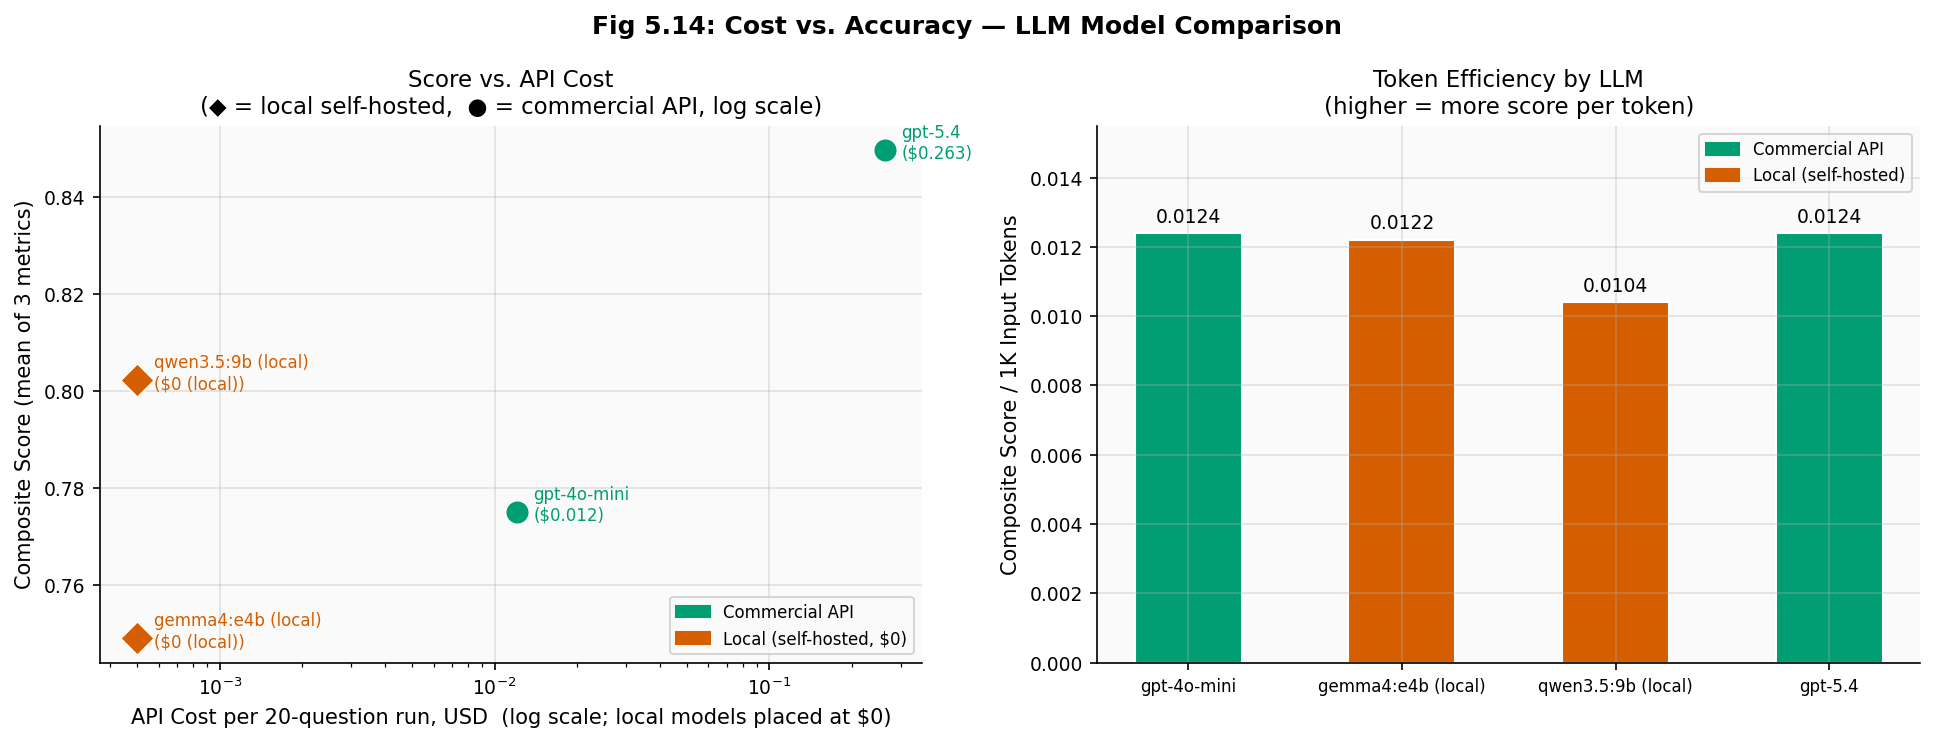

In [43]:
# ── Fig 5.14: Cost vs. Accuracy — LLM Model Comparison ────────────────────────
LOG_SCALE = True   # ← toggle: True = log scale, False = linear scale

EPS = 0.0005   # offset for local ($0) models on log scale; unused in linear mode

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Compute cost per run ────────────────────────────────────────────────────────
cost_points = []
for rid, label in AXIS3_RUNS_CLEAN:
    tok   = load_token_metrics(rid)
    meta  = MODEL_METADATA.get(tok.get('llm_model', ''), {})
    p_in  = meta.get('price_input_per_1M', 0.0)
    p_out = meta.get('price_output_per_1M', 0.0)
    cost  = (tok['total_llm_input_tokens'] * p_in +
             tok['total_llm_output_tokens'] * p_out) / 1e6
    score = mean_scores(all_data[rid])[METRIC_COLS].mean()
    is_local = (p_in == 0.0 and p_out == 0.0)
    cost_points.append({
        'label': label, 'cost': cost, 'score': score,
        'is_local': is_local,
        'color': PALETTE[3] if is_local else PALETTE[2],
    })

# ── Panel 1: Score vs. API cost ────────────────────────────────────────────────
ax = axes[0]
for d in cost_points:
    x = d['cost'] + (EPS if LOG_SCALE and d['is_local'] else 0)
    marker = 'D' if d['is_local'] else 'o'
    ax.scatter(x, d['score'], color=d['color'], s=130, zorder=3,
               marker=marker, edgecolors='white', linewidths=0.8)
    cost_str = '$0 (local)' if d['is_local'] else f"${d['cost']:.3f}"
    ax.annotate(f"{d['label']}\n({cost_str})",
                (x, d['score']), textcoords='offset points',
                xytext=(8, -4), fontsize=8, color=d['color'])

if LOG_SCALE:
    ax.set_xscale('log')
    ax.set_xlabel('API Cost per 20-question run, USD  (log scale; local models placed at $0)')
    ax.set_title('Score vs. API Cost\n(◆ = local self-hosted,  ● = commercial API, log scale)')
else:
    ax.set_xlabel('API Cost per 20-question run, USD')
    ax.set_title('Score vs. API Cost\n(◆ = local self-hosted,  ● = commercial API)')

ax.set_ylabel('Composite Score (mean of 3 metrics)')
ax.legend(handles=[
    mpatches.Patch(color=PALETTE[2], label='Commercial API'),
    mpatches.Patch(color=PALETTE[3], label='Local (self-hosted, $0)'),
], loc='lower right', fontsize=8)

# ── Panel 2: Score-per-1K-tokens (all 4 models) ────────────────────────────────
ax = axes[1]
labels_p2 = list(eff_axis3.index)
vals_p2   = eff_axis3['score_per_1k_tokens'].values
colors_p2 = [PALETTE[3] if '(local)' in lbl else PALETTE[2] for lbl in labels_p2]

bars = ax.bar(labels_p2, vals_p2, color=colors_p2, edgecolor='white', width=0.5)
for bar, v in zip(bars, vals_p2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.0002,
            f'{v:.4f}', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Composite Score / 1K Input Tokens')
ax.set_title('Token Efficiency by LLM\n(higher = more score per token)')
ax.set_ylim(0, max(vals_p2) * 1.25)
ax.tick_params(axis='x', labelsize=8)
ax.legend(handles=[
    mpatches.Patch(color=PALETTE[2], label='Commercial API'),
    mpatches.Patch(color=PALETTE[3], label='Local (self-hosted)'),
], loc='upper right', fontsize=8)

plt.suptitle('Fig 5.14: Cost vs. Accuracy — LLM Model Comparison',
             fontweight='bold')
plt.tight_layout()
savefig('fig_5_14_cost_vs_accuracy')
plt.show()